In [2]:
# part2_external_hierarchy_analysis.py
# ------------------------------------------------------------
# Part 2: Country-level violence vs external "hierarchy/patriarchy" proxies
# Uses:
#   - analysis_table_part2_allcountries.csv (must include iso3 + Violence_part2_all)
#   - external_country_datasets_v2.zip (UNDP HDR + V-Dem OWID exports)
#
# Outputs:
#   results_part2_external_hierarchy/
#     external_hierarchy_bayes_bootstrap.csv
#     analysis_table_part2_with_external_indicators.csv
#     figures/*.png + *.pdf
#
# Dependencies:
#   pip install numpy pandas scipy matplotlib
# ------------------------------------------------------------

from __future__ import annotations

import zipfile
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import rankdata, norm
from scipy.integrate import quad


# ----------------------------
# USER SETTINGS
# ----------------------------
OUTCOME_CSV = Path("results_paper_ready/hofstede_vs_violence_part2_bayes_nopymc_plus_FULL/analysis_table_part2_allcountries.csv")
EXTERNAL_ZIP = Path("external_country_datasets_v2.zip")

OUT_ROOT = Path("results_part2_external_hierarchy")
FIG_DIR = OUT_ROOT / "figures"

# Bayesian posterior sampling for summaries (importance resampling)
POST_SAMPLES = 200_000
RESAMPLE_N = 20_000
RANDOM_SEED = 42

# Bootstrap
BOOT_B = 20_000

# Plot
DPI_EXPORT = 600
SCATTER_ALPHA = 0.85


# ----------------------------
# Core stats
# ----------------------------
def spearman_rho(x, y) -> float:
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    if x.size < 3:
        return np.nan
    return float(np.corrcoef(rankdata(x), rankdata(y))[0, 1])


def posterior_z_norm_const(z_hat: float, se: float) -> float:
    # posterior in z: p(z|data) ∝ Normal(z | z_hat, se) * sech^2(z)
    def unnorm(z):
        return norm.pdf(z, loc=z_hat, scale=se) / (np.cosh(z) ** 2)
    return float(quad(unnorm, -20, 20, limit=200)[0])


def bayes_spearman_uniform_prior(x, y, seed=42):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    n = int(x.size)
    if n < 8:
        return None

    r = spearman_rho(x, y)
    r = float(np.clip(r, -0.999999, 0.999999))

    z_hat = float(np.arctanh(r))
    se = float(1.0 / np.sqrt(max(n - 3, 1)))

    Z = posterior_z_norm_const(z_hat, se)

    # rho=0 <-> z=0; Jacobian at 0 is 1
    post0 = float(norm.pdf(0.0, loc=z_hat, scale=se) / Z)
    prior0 = 0.5  # Uniform(-1,1) prior density at 0

    BF10 = float(prior0 / post0) if post0 > 0 else np.inf

    # Posterior summaries via importance resampling
    rng = np.random.default_rng(seed)
    z_prop = rng.normal(loc=z_hat, scale=se, size=POST_SAMPLES)
    w = 1.0 / (np.cosh(z_prop) ** 2)
    w = w / np.sum(w)
    idx = rng.choice(np.arange(POST_SAMPLES), size=RESAMPLE_N, replace=True, p=w)
    rho_post = np.tanh(z_prop[idx])

    return {
        "n": n,
        "spearman_r": float(r),
        "BF10": float(BF10),
        "P_rho_gt_0_post": float(np.mean(rho_post > 0)),
        "post_ci_low": float(np.quantile(rho_post, 0.025)),
        "post_ci_high": float(np.quantile(rho_post, 0.975)),
    }


def directional_bootstrap_spearman(x, y, B=20000, seed=42):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    n = int(x.size)
    if n < 8:
        return np.nan, np.nan, np.nan, np.nan, n

    def rho(a, b):
        return float(np.corrcoef(rankdata(a), rankdata(b))[0, 1])

    r0 = rho(x, y)
    boots = np.empty(B, float)
    for i in range(B):
        idx = rng.integers(0, n, size=n)
        boots[i] = rho(x[idx], y[idx])

    lo, hi = np.quantile(boots, [0.025, 0.975])
    p_gt0 = float(np.mean(boots > 0))
    return float(r0), float(lo), float(hi), p_gt0, n


# ----------------------------
# External data loaders
# ----------------------------
def unzip_external(zip_path: Path, out_dir: Path) -> Path:
    out_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(out_dir)
    return out_dir


def extract_undp_latest(hdr_csv: Path, prefix: str) -> pd.DataFrame:
    # HDR file is wide: <prefix>_YYYY columns (e.g., gii_2010, gii_2011, ...)
    hdr = pd.read_csv(hdr_csv, encoding="latin-1")
    hdr.columns = [str(c).strip() for c in hdr.columns]
    if "iso3" not in hdr.columns:
        raise ValueError(f"UNDP HDR file missing iso3 column: {hdr_csv}")
    hdr["iso3"] = hdr["iso3"].astype(str).str.upper()

    cols = [c for c in hdr.columns if re.match(fr"{prefix}_\d{{4}}$", str(c).lower())]
    if not cols:
        return pd.DataFrame(columns=["iso3", f"{prefix}_latest", f"{prefix}_year"])

    years = [int(c.split("_")[-1]) for c in cols]
    cols = [c for _, c in sorted(zip(years, cols))]  # ascending

    latest_vals = []
    latest_years = []
    for _, row in hdr.iterrows():
        vals = pd.to_numeric(row[cols], errors="coerce").to_numpy()
        yrs = [int(c.split("_")[-1]) for c in cols]
        # pick latest finite
        v_out = np.nan
        y_out = np.nan
        for v, y in reversed(list(zip(vals, yrs))):
            if np.isfinite(v):
                v_out = float(v)
                y_out = int(y)
                break
        latest_vals.append(v_out)
        latest_years.append(y_out)

    return pd.DataFrame({
        "iso3": hdr["iso3"],
        f"{prefix}_latest": latest_vals,
        f"{prefix}_year": latest_years,
    })


def owid_latest(owid_csv: Path, value_name: str) -> pd.DataFrame:
    # OWID grapher: Entity, Code, Year, <value>
    df = pd.read_csv(owid_csv)
    df["Code"] = df["Code"].astype(str).str.upper()
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

    valcol = [c for c in df.columns if c not in ["Entity", "Code", "Year"]][0]
    df[valcol] = pd.to_numeric(df[valcol], errors="coerce")

    df = df.dropna(subset=["Code", "Year", valcol]).sort_values("Year")
    latest = df.groupby("Code").tail(1)

    return latest[["Code", "Year", valcol]].rename(columns={
        "Code": "iso3",
        "Year": f"{value_name}_year",
        valcol: f"{value_name}_latest",
    })


# ----------------------------
# Plot helpers
# ----------------------------
def set_pub_style():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })


def savefig(fig, stem: str):
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG_DIR / f"{stem}.png", dpi=DPI_EXPORT, bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{stem}.pdf", bbox_inches="tight")
    plt.close(fig)


def forest_plot(df: pd.DataFrame, title: str, stem: str):
    set_pub_style()
    d = df.sort_values("spearman_r", ascending=True).reset_index(drop=True)
    y = np.arange(len(d))

    fig, ax = plt.subplots(figsize=(10, 5.8), dpi=300)
    ax.axvline(0.0, linewidth=1.2)

    for i, row in d.iterrows():
        ax.plot([row["boot_ci_low"], row["boot_ci_high"]], [i, i], linewidth=2.0)

    ax.scatter(d["spearman_r"], y, s=60, zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels([f'{row["indicator"]} (n={int(row["n"])})' for _, row in d.iterrows()])
    ax.set_xlabel("Spearman ρ (violence vs indicator)")
    ax.set_title(title)

    xmin, xmax = ax.get_xlim()
    xtext = xmax + 0.03 * (xmax - xmin)
    ax.set_xlim(xmin, xmax + 0.30 * (xmax - xmin))

    for i, row in d.iterrows():
        ax.text(
            xtext, i,
            f'BF10={row["BF10"]:.1f} | P(ρ>0)={row["P_rho_gt_0_post"]:.3f}',
            va="center", fontsize=10
        )

    savefig(fig, stem)


def bayes_direction_plot(df: pd.DataFrame, title: str, stem: str):
    set_pub_style()
    d = df.sort_values("BF10", ascending=True).reset_index(drop=True)
    y = np.arange(len(d))
    labels = [f'{row["indicator"]} (n={int(row["n"])})' for _, row in d.iterrows()]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.8), dpi=300, sharey=True)

    bf = np.clip(d["BF10"].to_numpy(), 1e-6, 1e9)
    ax1.axvline(0.0, linewidth=1.2)
    ax1.scatter(np.log10(bf), y, s=60)
    ax1.set_xlabel("log10(BF10)")
    ax1.set_title("Bayesian evidence")

    p = d["P_rho_gt_0_post"].to_numpy()
    ax2.axvline(0.5, linewidth=1.2)
    ax2.scatter(p, y, s=60)
    ax2.set_xlabel("Posterior P(ρ > 0)")
    ax2.set_title("Directional probability")

    ax2.set_yticks(y)
    ax2.set_yticklabels(labels)
    fig.suptitle(title, y=1.02)

    savefig(fig, stem)


def scatter_plot(df: pd.DataFrame, xcol: str, ycol: str, xlabel: str, ylabel: str, stem: str):
    set_pub_style()
    d = df[[xcol, ycol]].dropna()
    x = d[xcol].to_numpy()
    y = d[ycol].to_numpy()

    fig, ax = plt.subplots(figsize=(6.8, 5.6), dpi=300)
    ax.scatter(x, y, s=55, alpha=SCATTER_ALPHA)

    if len(x) >= 2:
        b1, b0 = np.polyfit(x, y, 1)
        xx = np.linspace(np.min(x), np.max(x), 200)
        ax.plot(xx, b1 * xx + b0, linewidth=2)

    r = spearman_rho(x, y)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{xlabel} vs {ylabel} (Spearman ρ={r:.2f}, n={len(x)})")

    savefig(fig, stem)


# ----------------------------
# MAIN
# ----------------------------
def main():
    if not OUTCOME_CSV.exists():
        raise FileNotFoundError(f"Missing {OUTCOME_CSV.resolve()}")
    if not EXTERNAL_ZIP.exists():
        raise FileNotFoundError(f"Missing {EXTERNAL_ZIP.resolve()}")

    OUT_ROOT.mkdir(parents=True, exist_ok=True)
    FIG_DIR.mkdir(parents=True, exist_ok=True)

    outcome = pd.read_csv(OUTCOME_CSV)
    needed = {"iso3", "Violence_part2_all"}
    if not needed.issubset(outcome.columns):
        raise ValueError(f"Outcome file must include {needed}. Got: {list(outcome.columns)}")
    outcome["iso3"] = outcome["iso3"].astype(str).str.upper()

    # Unzip external datasets
    ext_root = unzip_external(EXTERNAL_ZIP, OUT_ROOT / "external_unzipped")

    # Find UNDP + V-Dem files inside the extracted tree
    hdr_csv = next(ext_root.rglob("HDR_composite_indices_complete_time_series.csv"))
    vdem_dir = next(ext_root.rglob("vdem_owid"))

    # UNDP latest
    gii = extract_undp_latest(hdr_csv, "gii")
    gdi = extract_undp_latest(hdr_csv, "gdi")
    hdi = extract_undp_latest(hdr_csv, "hdi")

    # V-Dem latest (OWID grapher exports)
    vdem_tables = []
    for f in vdem_dir.glob("*.csv"):
        vdem_tables.append(owid_latest(f, f.stem))

    # Merge into one analysis table
    df = outcome[["iso3", "Violence_part2_all"]].copy()
    df = df.merge(gii, on="iso3", how="left").merge(gdi, on="iso3", how="left").merge(hdi, on="iso3", how="left")
    for t in vdem_tables:
        df = df.merge(t, on="iso3", how="left")

    df.to_csv(OUT_ROOT / "analysis_table_part2_with_external_indicators.csv", index=False)

    # Choose indicators to test (only those present)
    candidate_cols = [c for c in df.columns if c.endswith("_latest") and c != "Violence_part2_all_latest"]

    rows = []
    for col in candidate_cols:
        x = df[col].to_numpy()
        y = df["Violence_part2_all"].to_numpy()

        b = bayes_spearman_uniform_prior(x, y, seed=RANDOM_SEED)
        if b is None:
            continue

        r0, lo, hi, pgt0_boot, n_boot = directional_bootstrap_spearman(x, y, B=BOOT_B, seed=RANDOM_SEED)

        rows.append({
            "indicator": col.replace("_latest", ""),
            "n": int(b["n"]),
            "spearman_r": float(b["spearman_r"]),
            "BF10": float(b["BF10"]),
            "P_rho_gt_0_post": float(b["P_rho_gt_0_post"]),
            "post_ci_low": float(b["post_ci_low"]),
            "post_ci_high": float(b["post_ci_high"]),
            "boot_ci_low": float(lo),
            "boot_ci_high": float(hi),
            "boot_P_rho_gt_0": float(pgt0_boot),
        })

    res = pd.DataFrame(rows).sort_values("BF10", ascending=False).reset_index(drop=True)
    res.to_csv(OUT_ROOT / "external_hierarchy_bayes_bootstrap.csv", index=False)

    # Plots
    forest_plot(res, "Part 2: Violence vs external hierarchy proxies (bootstrap 95% CI)", "Fig_external_forest")
    bayes_direction_plot(res, "Part 2: External hierarchy proxies", "Fig_external_bf_direction")

    # Scatter for top 2 indicators by BF10
    for indname in res.head(2)["indicator"].tolist():
        scatter_plot(
            df,
            xcol=f"{indname}_latest",
            ycol="Violence_part2_all",
            xlabel=indname,
            ylabel="Violence_part2_all",
            stem=f"Scatter_{indname}",
        )

    print("[OK] Finished. Outputs in:", OUT_ROOT.resolve())
    print(res.head(10).to_string(index=False))


if __name__ == "__main__":
    main()


[OK] Finished. Outputs in: /home/carolinealves/Documents/violence-woman/results_part2_external_hierarchy
                        indicator  n  spearman_r         BF10  P_rho_gt_0_post  post_ci_low  post_ci_high  boot_ci_low  boot_ci_high  boot_P_rho_gt_0
                              gdi 67   -0.567443 60955.804593          0.00000    -0.701596     -0.358571    -0.715521     -0.374254          0.00000
                              hdi 69   -0.501325  2589.237792          0.00000    -0.650499     -0.287302    -0.688641     -0.274296          0.00000
        electoral-democracy-index 70   -0.496938  2427.423622          0.00000    -0.646651     -0.284561    -0.678921     -0.271434          0.00000
          liberal-democracy-index 70   -0.433094   166.033506          0.00005    -0.596284     -0.208818    -0.625669     -0.202871          0.00010
                              gii 66    0.443520   161.395522          0.99985     0.214814      0.609015     0.190783      0.664120          0.9

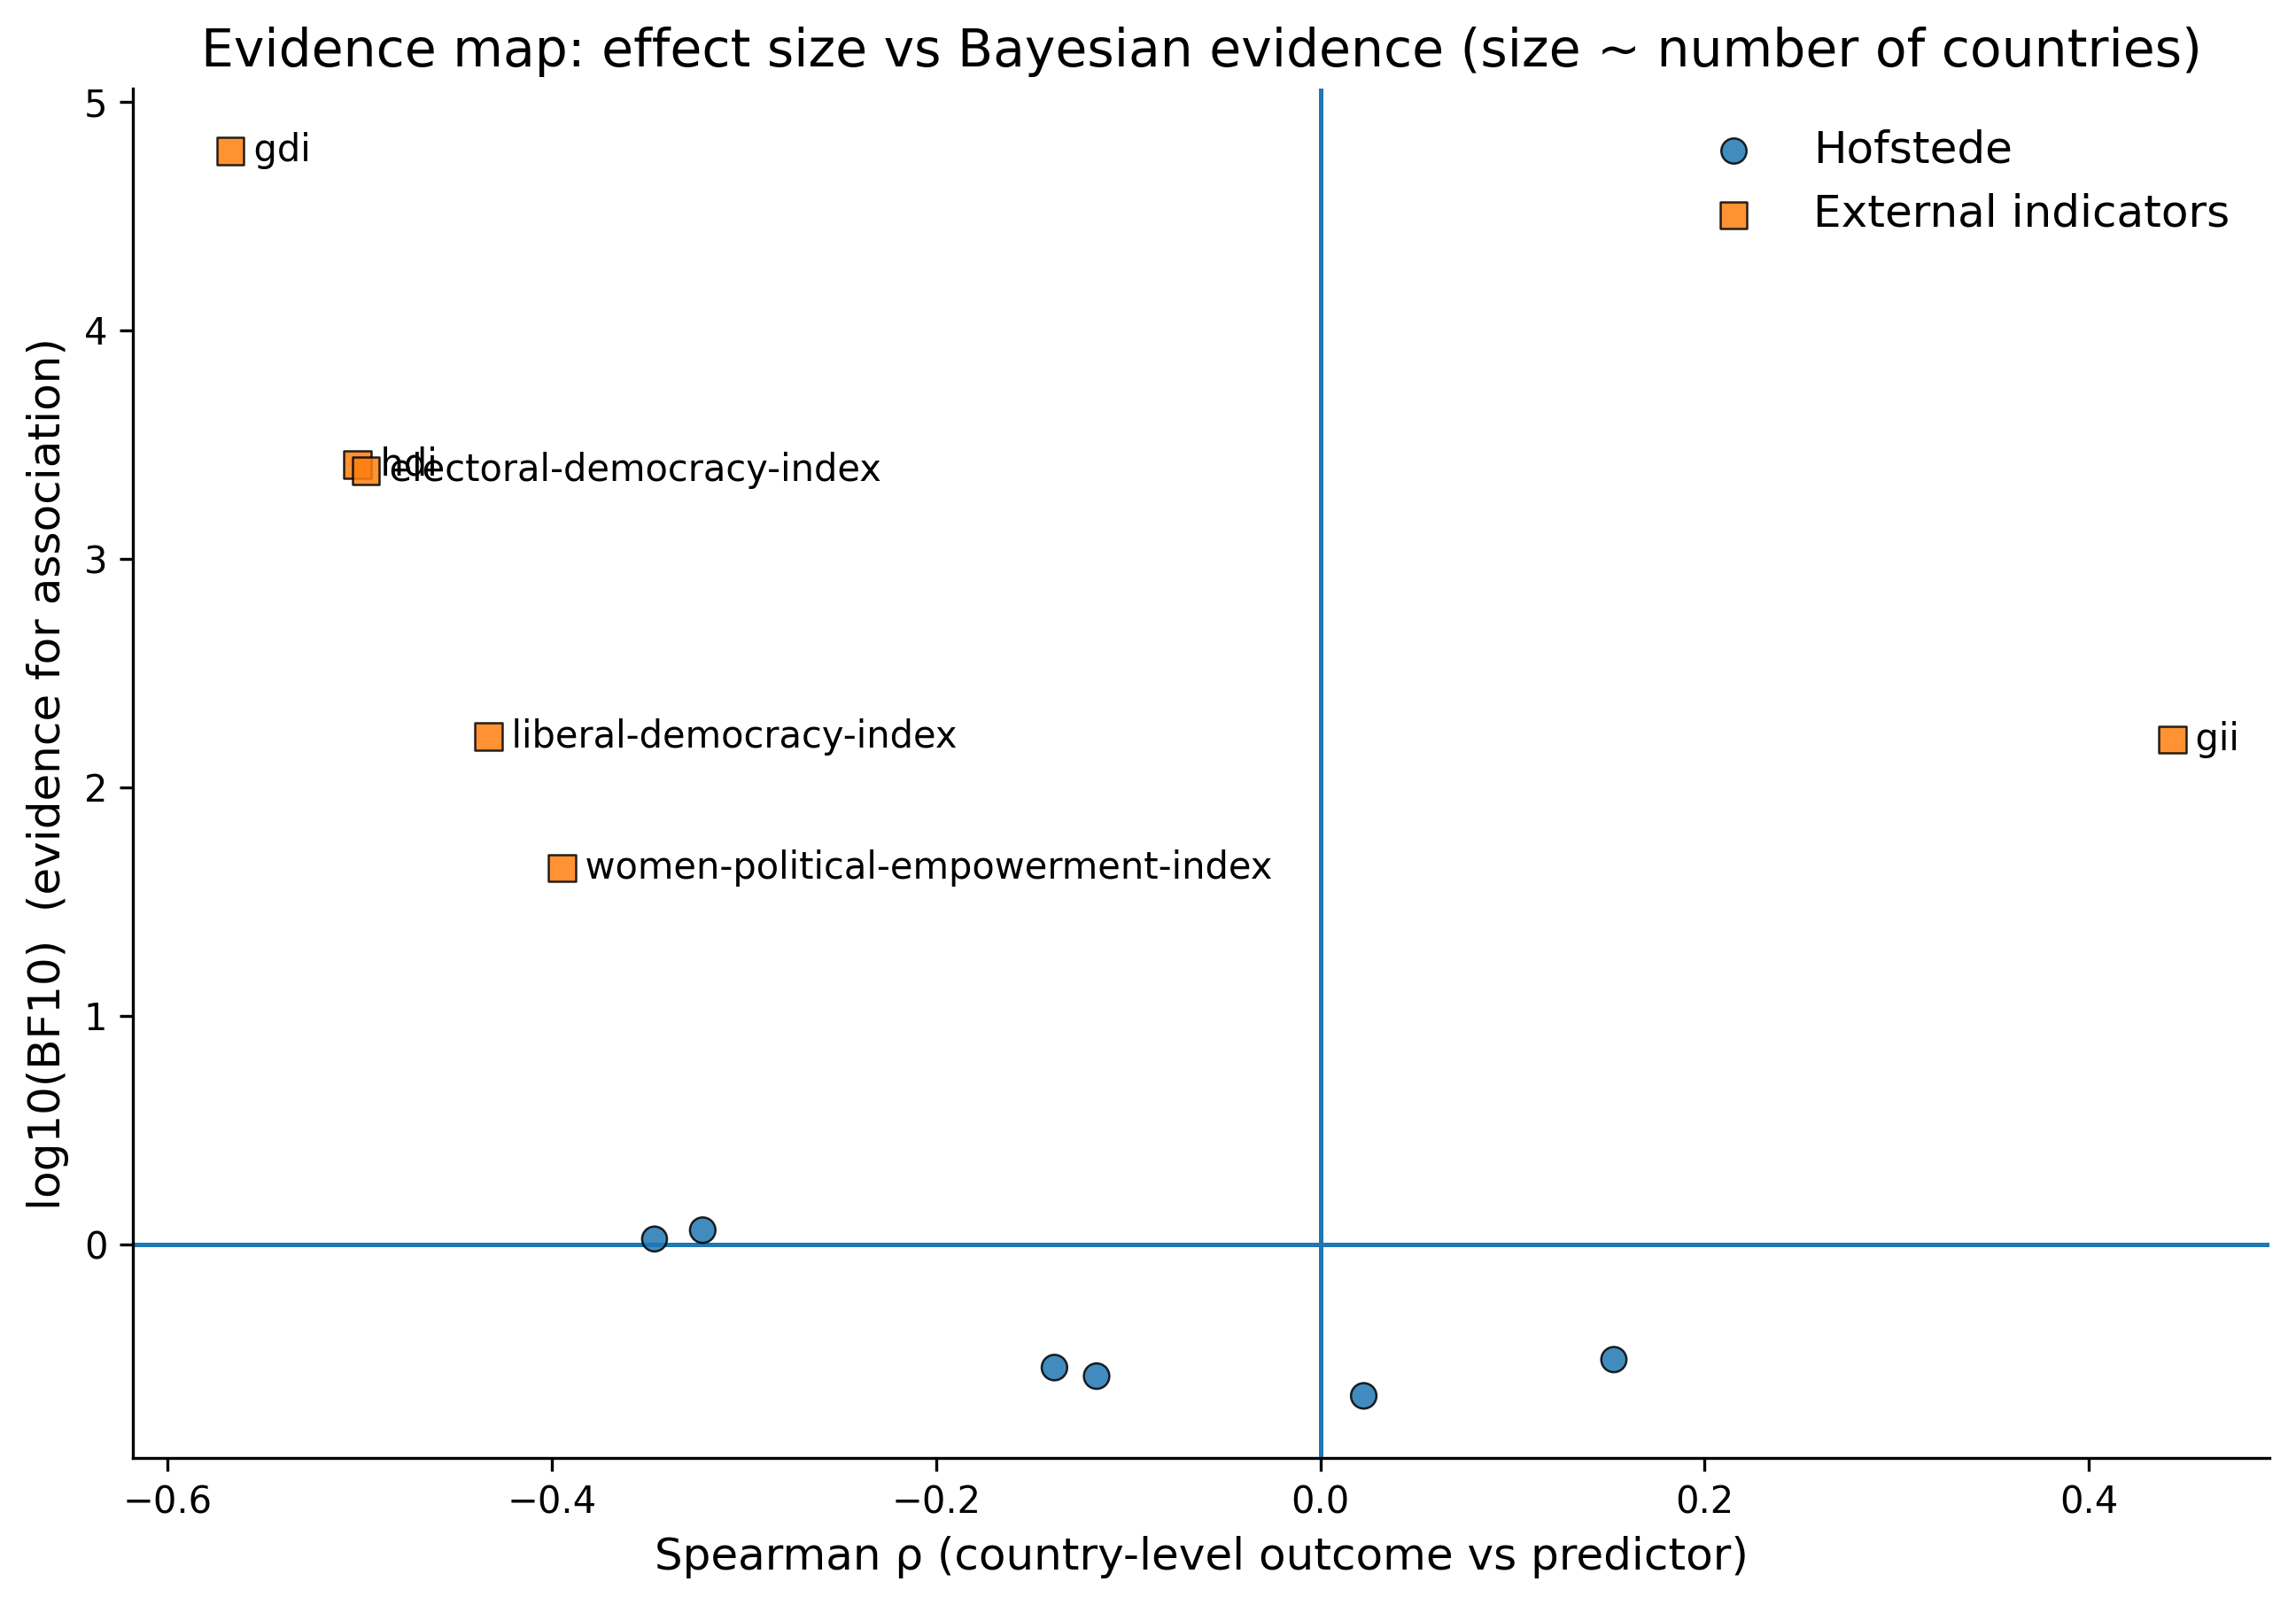

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EXTERNAL = "results_part2_external_hierarchy/external_hierarchy_bayes_bootstrap.csv"
# Change this to your hofstede output file if needed:
HOFSTEDE = "results_paper_ready/hofstede_vs_violence_part2_bayes_nopymc_plus_FULL/bayes_spearman_part2_all_plus.csv"  # or bayes_spearman_part2_all_plus_FULL output

def load_any(path, family_name):
    df = pd.read_csv(path)

    # try to standardize column names across your outputs
    colmap = {}
    for c in df.columns:
        lc = c.lower()
        if lc in ("hofstede_dim", "indicator", "variable", "predictor"):
            colmap[c] = "predictor"
        elif lc in ("spearman_r", "spearman_rho", "rho", "r"):
            colmap[c] = "rho"
        elif lc == "bf10":
            colmap[c] = "BF10"
        elif lc in ("n", "n_countries", "n_points"):
            colmap[c] = "n"
        elif lc in ("boot_ci_low", "ci_lo", "boot_lo"):
            colmap[c] = "ci_lo"
        elif lc in ("boot_ci_high", "ci_hi", "boot_hi"):
            colmap[c] = "ci_hi"
    df = df.rename(columns=colmap)

    # if predictor column missing, fall back to Hofstede_dim naming
    if "predictor" not in df.columns and "Hofstede_dim" in df.columns:
        df["predictor"] = df["Hofstede_dim"].astype(str)

    keep_cols = [c for c in ["predictor", "rho", "BF10", "n", "ci_lo", "ci_hi"] if c in df.columns]
    df = df[keep_cols].copy()
    df["family"] = family_name
    return df

ext = load_any(EXTERNAL, "External indicators")
hof = load_any(HOFSTEDE, "Hofstede")

# combine
all_df = pd.concat([hof, ext], ignore_index=True)
all_df = all_df.dropna(subset=["rho", "BF10"])
all_df["log10BF10"] = np.log10(np.clip(all_df["BF10"].to_numpy(float), 1e-6, 1e6))

# size scaling
if "n" in all_df.columns:
    n = pd.to_numeric(all_df["n"], errors="coerce").fillna(all_df["n"].median())
    sizes = 30 + 3.0 * np.sqrt(n)  # gentle scaling
else:
    sizes = np.full(len(all_df), 70.0)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, ax = plt.subplots(figsize=(8.8, 6.2), dpi=300)

# reference lines
ax.axvline(0.0, linewidth=1.2)
ax.axhline(0.0, linewidth=1.2)

# plot each family with different marker
for fam, marker in [("Hofstede", "o"), ("External indicators", "s")]:
    sub = all_df[all_df["family"] == fam].copy()
    if sub.empty:
        continue
    ax.scatter(
        sub["rho"].to_numpy(float),
        sub["log10BF10"].to_numpy(float),
        s=sizes[sub.index],
        marker=marker,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.6,
        label=fam,
        zorder=3
    )

# annotate only the most important predictors (top BF10)
top = all_df.sort_values("BF10", ascending=False).head(6)
for _, r in top.iterrows():
    ax.text(r["rho"], r["log10BF10"], "  " + str(r["predictor"]), va="center", fontsize=10)

ax.set_xlabel("Spearman ρ (country-level outcome vs predictor)")
ax.set_ylabel("log10(BF10)  (evidence for association)")
ax.set_title("Evidence map: effect size vs Bayesian evidence (size ~ number of countries)")
ax.legend(frameon=False, loc="best")

plt.tight_layout()
plt.show()


In [5]:
# plot_external_hierarchy_publication.py
# ------------------------------------------------------------
# Publication-ready plots (EXTERNAL indicators only):
#   FigA: Evidence map (Spearman ρ vs log10(BF10)) with clean labels
#   FigB: Heatmap summarizing strength + evidence + robustness
#
# Reads: external_hierarchy_bayes_bootstrap.csv
# Writes: figures_external_only/
#   - FigA_external_evidence_map.png/.pdf
#   - FigB_external_heatmap.png/.pdf
#
# Dependencies:
#   pip install numpy pandas matplotlib
# ------------------------------------------------------------

from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ----------------------------
# USER SETTINGS
# ----------------------------
EXTERNAL = Path("results_part2_external_hierarchy/external_hierarchy_bayes_bootstrap.csv")
OUTDIR   = Path("figures_external_only")

DPI_EXPORT = 600
TOP_LABELS = 8                 # label top by BF10 (and always label key ones)
LABEL_FONTSIZE = 10
POINT_ALPHA = 0.90

# Heatmap: which metrics to show (will keep those available in the CSV)
HEATMAP_METRICS_ORDER = [
    "rho", "log10BF10", "P_rho_gt_0_post", "boot_P_rho_gt_0_boot", "n", "ci_width"
]


# ----------------------------
# Helpers
# ----------------------------
def _standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Try to standardize your various outputs into common columns.
    Needed columns:
      predictor, rho, BF10, n, ci_lo, ci_hi
    Optional:
      P_rho_gt_0_post, boot_P_rho_gt_0_boot
    """
    df = df.copy()
    colmap = {}
    for c in df.columns:
        lc = str(c).strip().lower()
        if lc in ("indicator", "variable", "predictor", "hofstede_dim"):
            colmap[c] = "predictor"
        elif lc in ("spearman_r", "spearman_rho", "rho", "r"):
            colmap[c] = "rho"
        elif lc == "bf10":
            colmap[c] = "BF10"
        elif lc in ("n", "n_countries", "n_points"):
            colmap[c] = "n"
        elif lc in ("boot_ci_low", "ci_lo", "boot_lo"):
            colmap[c] = "ci_lo"
        elif lc in ("boot_ci_high", "ci_hi", "boot_hi"):
            colmap[c] = "ci_hi"
        elif lc in ("p_rho_gt_0_post", "p_rho_gt_0"):
            colmap[c] = "P_rho_gt_0_post"
        elif lc in ("boot_p_rho_gt_0_boot", "p_gt0_boot", "p_rho_gt_0_boot"):
            colmap[c] = "boot_P_rho_gt_0_boot"

    df = df.rename(columns=colmap)

    if "predictor" not in df.columns:
        raise ValueError("Could not find a predictor/indicator column in EXTERNAL CSV.")

    for c in ("rho", "BF10", "n", "ci_lo", "ci_hi", "P_rho_gt_0_post", "boot_P_rho_gt_0_boot"):
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    df["predictor"] = df["predictor"].astype(str)
    df = df.dropna(subset=["rho", "BF10"]).copy()

    # derived columns
    df["log10BF10"] = np.log10(np.clip(df["BF10"].to_numpy(float), 1e-12, 1e12))
    if "ci_lo" in df.columns and "ci_hi" in df.columns:
        df["ci_width"] = (df["ci_hi"] - df["ci_lo"]).astype(float)
    else:
        df["ci_width"] = np.nan

    return df


def _pretty_label(s: str) -> str:
    """Make labels shorter / paper-friendly."""
    s0 = str(s)

    repl = {
        "electoral-democracy-index": "Electoral democracy",
        "liberal-democracy-index": "Liberal democracy",
        "women-political-empowerment-index": "Women political empowerment",
        "gii": "Gender Inequality Index (GII)",
        "gdi": "Gender Development Index (GDI)",
        "hdi": "Human Development Index (HDI)",
    }
    key = s0.strip().lower().replace(" ", "-")
    return repl.get(key, s0)


def set_pub_style():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })


def savefig(fig, out_png: Path, out_pdf: Path):
    out_png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, dpi=DPI_EXPORT, bbox_inches="tight")
    fig.savefig(out_pdf, bbox_inches="tight")
    plt.close(fig)


def size_from_n(n: pd.Series) -> np.ndarray:
    n2 = pd.to_numeric(n, errors="coerce")
    if n2.notna().sum() == 0:
        return np.full(len(n), 70.0)
    med = float(np.nanmedian(n2))
    n2 = n2.fillna(med).to_numpy(float)
    # gentle scaling
    return 40.0 + 3.5 * np.sqrt(np.clip(n2, 1, None))


# ----------------------------
# FigA: Evidence map (EXTERNAL only)
# ----------------------------
def plot_evidence_map_external(df: pd.DataFrame, outdir: Path):
    set_pub_style()

    d = df.copy()
    d["label"] = d["predictor"].map(_pretty_label)

    # pick which to label:
    top_by_bf = d.sort_values("BF10", ascending=False).head(TOP_LABELS)["predictor"].tolist()
    always = set()
    for name in ("gdi", "gii", "electoral-democracy-index", "liberal-democracy-index", "women-political-empowerment-index"):
        if (d["predictor"].astype(str).str.lower() == name).any():
            always.add(d.loc[d["predictor"].astype(str).str.lower() == name, "predictor"].iloc[0])
    to_label = set(top_by_bf) | always

    fig, ax = plt.subplots(figsize=(9.2, 6.3), dpi=300)

    # reference lines
    ax.axvline(0.0, linewidth=1.2)
    ax.axhline(0.0, linewidth=1.2)

    sizes = size_from_n(d["n"]) if "n" in d.columns else np.full(len(d), 70.0)

    ax.scatter(
        d["rho"].to_numpy(float),
        d["log10BF10"].to_numpy(float),
        s=sizes,
        marker="s",
        alpha=POINT_ALPHA,
        edgecolor="black",
        linewidth=0.7,
        zorder=3
    )

    # label placement with deterministic offsets to reduce overlap
    # (no external deps like adjustText)
    dx = 0.012
    dy = 0.05
    signed = np.sign(d["rho"].to_numpy(float))
    if np.all(signed == 0):
        signed = np.ones_like(signed)

    for i, r in d.iterrows():
        if r["predictor"] not in to_label:
            continue
        x = float(r["rho"])
        y = float(r["log10BF10"])
        # offset labels away from the point, direction depends on rho sign
        offx = dx * (1.0 if x >= 0 else -1.0)
        offy = dy * (1.0 if (i % 2 == 0) else -1.0)
        ax.text(
            x + offx, y + offy,
            str(r["label"]),
            fontsize=LABEL_FONTSIZE,
            va="center",
            ha=("left" if x >= 0 else "right")
        )

    ax.set_xlabel("Spearman ρ (country-level outcome vs indicator)")
    ax.set_ylabel("log10(BF10)  (Bayesian evidence for association)")
    ax.set_title("External hierarchy/gender indicators: effect size vs Bayesian evidence\n(point size ∝ number of countries)")

    # Make axes limits slightly padded
    xr = d["rho"].to_numpy(float)
    yr = d["log10BF10"].to_numpy(float)
    ax.set_xlim(float(np.nanmin(xr) - 0.06), float(np.nanmax(xr) + 0.06))
    ax.set_ylim(float(np.nanmin(yr) - 0.4), float(np.nanmax(yr) + 0.4))

    plt.tight_layout()

    savefig(
        fig,
        outdir / "FigA_external_evidence_map.png",
        outdir / "FigA_external_evidence_map.pdf"
    )


# ----------------------------
# FigB: Heatmap summary (EXTERNAL only)
# ----------------------------
def plot_external_heatmap(df: pd.DataFrame, outdir: Path):
    set_pub_style()
    d = df.copy()
    d["label"] = d["predictor"].map(_pretty_label)

    # choose metrics that exist
    available = []
    for m in HEATMAP_METRICS_ORDER:
        if m in d.columns:
            available.append(m)

    if not available:
        raise ValueError("No heatmap metrics available in the EXTERNAL CSV.")

    # Build matrix
    H = d[available].copy()

    # Make sure numeric
    for c in available:
        H[c] = pd.to_numeric(H[c], errors="coerce")

    # Optional transform:
    # - keep rho as is (signed)
    # - log10BF10 as is
    # - n as log10(n) to avoid scale dominance
    if "n" in H.columns:
        H["n"] = np.log10(np.clip(H["n"].to_numpy(float), 1, None))

    # For "ci_width": smaller is better robustness, so invert sign to mean "better" is larger
    if "ci_width" in H.columns:
        H["ci_width"] = -H["ci_width"].to_numpy(float)

    # Standardize columns (z-score) so heatmap is comparable across metrics
    M = H.to_numpy(float)
    col_mu = np.nanmean(M, axis=0)
    col_sd = np.nanstd(M, axis=0, ddof=1)
    col_sd = np.where(col_sd == 0, 1.0, col_sd)
    Z = (M - col_mu) / col_sd

    # Order rows by evidence strength primarily
    order = d.sort_values(["BF10", "rho"], ascending=[False, True]).index.to_numpy()
    Z = Z[np.argsort(np.argsort(order))]  # align with d if needed (safe)
    # Better: reorder directly using sorted indices
    d_ord = d.loc[order].reset_index(drop=True)
    H_ord = H.loc[order].reset_index(drop=True)
    M_ord = H_ord.to_numpy(float)
    col_mu = np.nanmean(M_ord, axis=0)
    col_sd = np.nanstd(M_ord, axis=0, ddof=1)
    col_sd = np.where(col_sd == 0, 1.0, col_sd)
    Z_ord = (M_ord - col_mu) / col_sd

    # Plot
    fig, ax = plt.subplots(figsize=(10.5, max(3.8, 0.55 * len(d_ord) + 1.5)), dpi=300)

    im = ax.imshow(Z_ord, aspect="auto")  # default colormap (do not force colors)

    ax.set_yticks(np.arange(len(d_ord)))
    ax.set_yticklabels(d_ord["label"].tolist())

    # nicer column names
    col_pretty = {
        "rho": "Spearman ρ",
        "log10BF10": "log10(BF10)",
        "P_rho_gt_0_post": "Posterior P(ρ>0)",
        "boot_P_rho_gt_0_boot": "Bootstrap P(ρ>0)",
        "n": "log10(n_countries)",
        "ci_width": "−CI width (robustness)",
    }
    ax.set_xticks(np.arange(len(available)))
    ax.set_xticklabels([col_pretty.get(c, c) for c in available], rotation=30, ha="right")

    ax.set_title("External indicators: standardized summary of effect, evidence, and robustness")

    # annotate with raw (non-z) values (compact)
    # (keep short; do not over-clutter)
    for i in range(len(d_ord)):
        for j, c in enumerate(available):
            val = H_ord.iloc[i, j]
            if np.isfinite(val):
                if c in ("rho", "P_rho_gt_0_post", "boot_P_rho_gt_0_boot"):
                    txt = f"{val:.2f}"
                elif c == "log10BF10":
                    txt = f"{val:.1f}"
                elif c == "n":
                    txt = f"{val:.2f}"  # log10(n)
                else:
                    txt = f"{val:.2f}"
                ax.text(j, i, txt, ha="center", va="center", fontsize=9)

    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("Column-wise z-score")

    plt.tight_layout()

    savefig(
        fig,
        outdir / "FigB_external_heatmap.png",
        outdir / "FigB_external_heatmap.pdf"
    )


# ----------------------------
# MAIN
# ----------------------------
def main():
    if not EXTERNAL.exists():
        raise FileNotFoundError(f"Cannot find EXTERNAL CSV: {EXTERNAL.resolve()}")

    OUTDIR.mkdir(parents=True, exist_ok=True)

    df_raw = pd.read_csv(EXTERNAL)
    df = _standardize_columns(df_raw)

    # Keep only EXTERNAL indicators (you requested Hofstede removed)
    # (This script assumes EXTERNAL CSV already contains only external indicators.)
    # If it contains mixed families, filter here by a 'family' column if present.

    plot_evidence_map_external(df, OUTDIR)
    plot_external_heatmap(df, OUTDIR)

    # Save a clean table used for plotting (good for supplements)
    out_table = df.copy()
    out_table["pretty_label"] = out_table["predictor"].map(_pretty_label)
    out_table.to_csv(OUTDIR / "external_indicators_table_for_figures.csv", index=False)

    print("\n[OK] Done. Figures written to:", OUTDIR.resolve())
    print("[OK] Files:")
    print(" - FigA_external_evidence_map.(png/pdf)")
    print(" - FigB_external_heatmap.(png/pdf)")
    print(" - external_indicators_table_for_figures.csv")


if __name__ == "__main__":
    main()



[OK] Done. Figures written to: /home/carolinealves/Documents/violence-woman/figures_external_only
[OK] Files:
 - FigA_external_evidence_map.(png/pdf)
 - FigB_external_heatmap.(png/pdf)
 - external_indicators_table_for_figures.csv


In [6]:
# plot_hofstede_publication.py
# ------------------------------------------------------------
# Publication-ready plots (HOFSTEDE only):
#   FigA: Evidence map (Spearman ρ vs log10(BF10)) with clean labels
#   FigB: Heatmap summarizing strength + evidence + robustness
#
# Reads: a Hofstede results CSV with columns like:
#   Hofstede_dim, spearman_r (or Spearman_rho/rho), BF10, n, boot_ci_low/boot_ci_high,
#   P_rho_gt_0_post, boot_P_rho_gt_0_boot (optional)
#
# Writes: figures_hofstede_only/
#   - FigA_hofstede_evidence_map.png/.pdf
#   - FigB_hofstede_heatmap.png/.pdf
#
# Dependencies:
#   pip install numpy pandas matplotlib
# ------------------------------------------------------------

from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ----------------------------
# USER SETTINGS
# ----------------------------
HOFSTEDE = Path("results_paper_ready/hofstede_vs_violence_part2_bayes_nopymc_plus_FULL/bayes_spearman_part2_all_plus.csv")
OUTDIR   = Path("figures_hofstede_only")

DPI_EXPORT = 600
TOP_LABELS = 8
LABEL_FONTSIZE = 10
POINT_ALPHA = 0.90

HEATMAP_METRICS_ORDER = [
    "rho", "log10BF10", "P_rho_gt_0_post", "boot_P_rho_gt_0_boot", "n", "ci_width"
]


# ----------------------------
# Helpers
# ----------------------------
def _standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    colmap = {}
    for c in df.columns:
        lc = str(c).strip().lower()
        if lc in ("hofstede_dim", "indicator", "variable", "predictor"):
            colmap[c] = "predictor"
        elif lc in ("spearman_r", "spearman_rho", "rho", "r"):
            colmap[c] = "rho"
        elif lc == "bf10":
            colmap[c] = "BF10"
        elif lc in ("n", "n_countries", "n_points"):
            colmap[c] = "n"
        elif lc in ("boot_ci_low", "ci_lo", "boot_lo"):
            colmap[c] = "ci_lo"
        elif lc in ("boot_ci_high", "ci_hi", "boot_hi"):
            colmap[c] = "ci_hi"
        elif lc in ("p_rho_gt_0_post", "p_rho_gt_0"):
            colmap[c] = "P_rho_gt_0_post"
        elif lc in ("boot_p_rho_gt_0_boot", "p_gt0_boot", "p_rho_gt_0_boot"):
            colmap[c] = "boot_P_rho_gt_0_boot"

    df = df.rename(columns=colmap)

    if "predictor" not in df.columns:
        raise ValueError("Could not find a predictor column (expected Hofstede_dim or similar).")

    for c in ("rho", "BF10", "n", "ci_lo", "ci_hi", "P_rho_gt_0_post", "boot_P_rho_gt_0_boot"):
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    df["predictor"] = df["predictor"].astype(str)
    df = df.dropna(subset=["rho", "BF10"]).copy()

    df["log10BF10"] = np.log10(np.clip(df["BF10"].to_numpy(float), 1e-12, 1e12))
    if "ci_lo" in df.columns and "ci_hi" in df.columns:
        df["ci_width"] = (df["ci_hi"] - df["ci_lo"]).astype(float)
    else:
        df["ci_width"] = np.nan

    return df


def _pretty_label(s: str) -> str:
    """
    Optional: map your Hofstede abbreviations to readable labels for the figure.
    Adjust to match your column naming.
    """
    s0 = str(s).strip()
    repl = {
        "pdi": "Power distance (PDI)",
        "idv": "Individualism (IDV)",
        "mas": "Masculinity (MAS)",
        "uai": "Uncertainty avoidance (UAI)",
        "lto": "Long-term orientation (LTO)",
        "ivr": "Indulgence (IVR)",
    }
    key = s0.lower()
    return repl.get(key, s0)


def set_pub_style():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })


def savefig(fig, out_png: Path, out_pdf: Path):
    out_png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, dpi=DPI_EXPORT, bbox_inches="tight")
    fig.savefig(out_pdf, bbox_inches="tight")
    plt.close(fig)


def size_from_n(n: pd.Series) -> np.ndarray:
    n2 = pd.to_numeric(n, errors="coerce")
    if n2.notna().sum() == 0:
        return np.full(len(n), 70.0)
    med = float(np.nanmedian(n2))
    n2 = n2.fillna(med).to_numpy(float)
    return 40.0 + 3.5 * np.sqrt(np.clip(n2, 1, None))


# ----------------------------
# FigA: Evidence map (Hofstede only)
# ----------------------------
def plot_evidence_map_hofstede(df: pd.DataFrame, outdir: Path):
    set_pub_style()
    d = df.copy()
    d["label"] = d["predictor"].map(_pretty_label)

    top_by_bf = d.sort_values("BF10", ascending=False).head(TOP_LABELS)["predictor"].tolist()
    to_label = set(top_by_bf)

    fig, ax = plt.subplots(figsize=(9.2, 6.3), dpi=300)
    ax.axvline(0.0, linewidth=1.2)
    ax.axhline(0.0, linewidth=1.2)

    sizes = size_from_n(d["n"]) if "n" in d.columns else np.full(len(d), 70.0)

    ax.scatter(
        d["rho"].to_numpy(float),
        d["log10BF10"].to_numpy(float),
        s=sizes,
        marker="o",
        alpha=POINT_ALPHA,
        edgecolor="black",
        linewidth=0.7,
        zorder=3
    )

    dx = 0.012
    dy = 0.05
    for i, r in d.iterrows():
        if r["predictor"] not in to_label:
            continue
        x = float(r["rho"])
        y = float(r["log10BF10"])
        offx = dx * (1.0 if x >= 0 else -1.0)
        offy = dy * (1.0 if (i % 2 == 0) else -1.0)
        ax.text(
            x + offx, y + offy,
            str(r["label"]),
            fontsize=LABEL_FONTSIZE,
            va="center",
            ha=("left" if x >= 0 else "right")
        )

    ax.set_xlabel("Spearman ρ (country-level outcome vs Hofstede dimension)")
    ax.set_ylabel("log10(BF10)  (Bayesian evidence for association)")
    ax.set_title("Hofstede dimensions: effect size vs Bayesian evidence\n(point size ∝ number of countries)")

    xr = d["rho"].to_numpy(float)
    yr = d["log10BF10"].to_numpy(float)
    ax.set_xlim(float(np.nanmin(xr) - 0.06), float(np.nanmax(xr) + 0.06))
    ax.set_ylim(float(np.nanmin(yr) - 0.4), float(np.nanmax(yr) + 0.4))

    plt.tight_layout()

    savefig(
        fig,
        outdir / "FigA_hofstede_evidence_map.png",
        outdir / "FigA_hofstede_evidence_map.pdf"
    )


# ----------------------------
# FigB: Heatmap summary (Hofstede only)
# ----------------------------
def plot_hofstede_heatmap(df: pd.DataFrame, outdir: Path):
    set_pub_style()
    d = df.copy()
    d["label"] = d["predictor"].map(_pretty_label)

    available = [m for m in HEATMAP_METRICS_ORDER if m in d.columns]
    if not available:
        raise ValueError("No heatmap metrics available in the Hofstede CSV.")

    H = d[available].copy()
    for c in available:
        H[c] = pd.to_numeric(H[c], errors="coerce")

    if "n" in H.columns:
        H["n"] = np.log10(np.clip(H["n"].to_numpy(float), 1, None))
    if "ci_width" in H.columns:
        H["ci_width"] = -H["ci_width"].to_numpy(float)

    order = d.sort_values(["BF10", "rho"], ascending=[False, True]).index.to_numpy()
    d_ord = d.loc[order].reset_index(drop=True)
    H_ord = H.loc[order].reset_index(drop=True)

    M_ord = H_ord.to_numpy(float)
    col_mu = np.nanmean(M_ord, axis=0)
    col_sd = np.nanstd(M_ord, axis=0, ddof=1)
    col_sd = np.where(col_sd == 0, 1.0, col_sd)
    Z_ord = (M_ord - col_mu) / col_sd

    fig, ax = plt.subplots(figsize=(10.5, max(3.8, 0.55 * len(d_ord) + 1.5)), dpi=300)
    im = ax.imshow(Z_ord, aspect="auto")

    ax.set_yticks(np.arange(len(d_ord)))
    ax.set_yticklabels(d_ord["label"].tolist())

    col_pretty = {
        "rho": "Spearman ρ",
        "log10BF10": "log10(BF10)",
        "P_rho_gt_0_post": "Posterior P(ρ>0)",
        "boot_P_rho_gt_0_boot": "Bootstrap P(ρ>0)",
        "n": "log10(n_countries)",
        "ci_width": "−CI width (robustness)",
    }
    ax.set_xticks(np.arange(len(available)))
    ax.set_xticklabels([col_pretty.get(c, c) for c in available], rotation=30, ha="right")

    ax.set_title("Hofstede dimensions: standardized summary of effect, evidence, and robustness")

    for i in range(len(d_ord)):
        for j, c in enumerate(available):
            val = H_ord.iloc[i, j]
            if np.isfinite(val):
                if c in ("rho", "P_rho_gt_0_post", "boot_P_rho_gt_0_boot"):
                    txt = f"{val:.2f}"
                elif c == "log10BF10":
                    txt = f"{val:.1f}"
                elif c == "n":
                    txt = f"{val:.2f}"
                else:
                    txt = f"{val:.2f}"
                ax.text(j, i, txt, ha="center", va="center", fontsize=9)

    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("Column-wise z-score")

    plt.tight_layout()

    savefig(
        fig,
        outdir / "FigB_hofstede_heatmap.png",
        outdir / "FigB_hofstede_heatmap.pdf"
    )


# ----------------------------
# MAIN
# ----------------------------
def main():
    if not HOFSTEDE.exists():
        raise FileNotFoundError(f"Cannot find Hofstede CSV: {HOFSTEDE.resolve()}")

    OUTDIR.mkdir(parents=True, exist_ok=True)

    df_raw = pd.read_csv(HOFSTEDE)
    df = _standardize_columns(df_raw)

    plot_evidence_map_hofstede(df, OUTDIR)
    plot_hofstede_heatmap(df, OUTDIR)

    out_table = df.copy()
    out_table["pretty_label"] = out_table["predictor"].map(_pretty_label)
    out_table.to_csv(OUTDIR / "hofstede_table_for_figures.csv", index=False)

    print("\n[OK] Done. Figures written to:", OUTDIR.resolve())
    print("[OK] Files:")
    print(" - FigA_hofstede_evidence_map.(png/pdf)")
    print(" - FigB_hofstede_heatmap.(png/pdf)")
    print(" - hofstede_table_for_figures.csv")


if __name__ == "__main__":
    main()



[OK] Done. Figures written to: /home/carolinealves/Documents/violence-woman/figures_hofstede_only
[OK] Files:
 - FigA_hofstede_evidence_map.(png/pdf)
 - FigB_hofstede_heatmap.(png/pdf)
 - hofstede_table_for_figures.csv


In [8]:
# plot_country_profiles_external.py
# ------------------------------------------------------------
# Country-focused plots for EXTERNAL hierarchy/gender indicators
# using analysis_table_part2_with_external_indicators.csv
#
# Creates, for each country list:
#   (1) Heatmap of z-scored indicator profiles
#   (2) Heatmap of percentile ranks (0..100) per indicator
#   (3) Scatter grid: Violence_part2_all vs each indicator, selected countries highlighted
#
# Dependencies:
#   pip install pandas numpy matplotlib pycountry
# ------------------------------------------------------------

from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import pycountry
    HAS_PYCOUNTRY = True
except Exception:
    HAS_PYCOUNTRY = False

# ----------------------------
# USER SETTINGS
# ----------------------------
DATA = Path("results_part2_external_hierarchy/analysis_table_part2_with_external_indicators.csv")  # adjust if needed
OUTDIR = Path("figures_by_countries_external")
DPI_EXPORT = 600

# Your requested country sets
COUNTRIES_PART1 = ["Afghanistan", "Madagascar", "Gambia", "Malawi", "Morocco"]
COUNTRIES_PART2 = ["Ethiopia", "Niger", "Morocco", "Senegal", "Benin"]

# Indicators (columns in your CSV)
INDICATOR_COLS = [
    "gii_latest",
    "gdi_latest",
    "hdi_latest",
    "electoral-democracy-index_latest",
    "liberal-democracy-index_latest",
    "women-political-empowerment-index_latest",
]

# Pretty labels (for plots)
PRETTY = {
    "gii_latest": "Gender Inequality Index (GII)",
    "gdi_latest": "Gender Development Index (GDI)",
    "hdi_latest": "Human Development Index (HDI)",
    "electoral-democracy-index_latest": "Electoral democracy",
    "liberal-democracy-index_latest": "Liberal democracy",
    "women-political-empowerment-index_latest": "Women political empowerment",
}

# ----------------------------
# Helpers
# ----------------------------
def set_pub_style():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })

def savefig(fig, out_png: Path, out_pdf: Path):
    out_png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, dpi=DPI_EXPORT, bbox_inches="tight")
    fig.savefig(out_pdf, bbox_inches="tight")
    plt.close(fig)

def iso3_from_name(name: str) -> str | None:
    overrides = {
        "Morocco": "MAR",
        "Gambia": "GMB",
        "Cote d'Ivoire": "CIV",
        "Ivory Coast": "CIV",
        "Cape Verde": "CPV",
        "Eswatini": "SWZ",
    }
    if name in overrides:
        return overrides[name]
    if not HAS_PYCOUNTRY:
        return None
    try:
        c = pycountry.countries.lookup(name)
        return getattr(c, "alpha_3", None)
    except Exception:
        return None

def name_from_iso3(iso3: str) -> str:
    if not HAS_PYCOUNTRY:
        return iso3
    try:
        c = pycountry.countries.get(alpha_3=str(iso3))
        return c.name if c else str(iso3)
    except Exception:
        return str(iso3)

def zscore_columns(M: pd.DataFrame) -> pd.DataFrame:
    X = M.to_numpy(float)
    mu = np.nanmean(X, axis=0)
    sd = np.nanstd(X, axis=0, ddof=1)
    sd = np.where(sd == 0, 1.0, sd)
    Z = (X - mu) / sd
    return pd.DataFrame(Z, index=M.index, columns=M.columns)

def percentile_columns(M: pd.DataFrame) -> pd.DataFrame:
    # percentile rank per column (0..100)
    out = {}
    for col in M.columns:
        x = pd.to_numeric(M[col], errors="coerce")
        # rank among non-nan
        r = x.rank(pct=True) * 100.0
        out[col] = r
    return pd.DataFrame(out, index=M.index)

def plot_heatmap(matrix: pd.DataFrame, title: str, outbase: Path, annotate_fmt: str):
    set_pub_style()
    fig, ax = plt.subplots(figsize=(10.8, max(3.2, 0.65 * len(matrix) + 1.2)), dpi=300)
    im = ax.imshow(matrix.to_numpy(float), aspect="auto")

    ax.set_yticks(np.arange(len(matrix)))
    ax.set_yticklabels(matrix.index.tolist())

    ax.set_xticks(np.arange(len(matrix.columns)))
    ax.set_xticklabels([PRETTY.get(c, c) for c in matrix.columns], rotation=30, ha="right")

    ax.set_title(title)

    # annotate values
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            val = matrix.iat[i, j]
            if np.isfinite(val):
                ax.text(j, i, annotate_fmt.format(val), ha="center", va="center", fontsize=9)

    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("Value")

    plt.tight_layout()
    savefig(fig, outbase.with_suffix(".png"), outbase.with_suffix(".pdf"))

def plot_scatter_grid(df_all: pd.DataFrame, df_sel: pd.DataFrame, title: str, outbase: Path):
    set_pub_style()
    k = len(INDICATOR_COLS)
    ncols = 3
    nrows = int(np.ceil(k / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14.5, 4.2 * nrows), dpi=300)
    axes = np.array(axes).reshape(nrows, ncols)

    y = pd.to_numeric(df_all["Violence_part2_all"], errors="coerce")

    for idx, col in enumerate(INDICATOR_COLS):
        r, c = divmod(idx, ncols)
        ax = axes[r, c]
        x = pd.to_numeric(df_all[col], errors="coerce")

        # all countries
        ax.scatter(x, y, s=35, alpha=0.55, edgecolor="none")

        # selected countries highlighted
        xs = pd.to_numeric(df_sel[col], errors="coerce")
        ys = pd.to_numeric(df_sel["Violence_part2_all"], errors="coerce")
        ax.scatter(xs, ys, s=90, marker="s", edgecolor="black", linewidth=0.8)

        # labels
        for _, rr in df_sel.iterrows():
            ax.text(rr[col], rr["Violence_part2_all"], "  " + rr["country_name"],
                    va="center", fontsize=10)

        ax.set_xlabel(PRETTY.get(col, col))
        ax.set_ylabel("Violence_part2_all" if c == 0 else "")
        ax.set_title(PRETTY.get(col, col))

    # hide empty panels
    for j in range(k, nrows * ncols):
        r, c = divmod(j, ncols)
        axes[r, c].axis("off")

    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    savefig(fig, outbase.with_suffix(".png"), outbase.with_suffix(".pdf"))

def make_bundle(country_names: list[str], tag: str, df: pd.DataFrame):
    iso3_list = [iso3_from_name(n) for n in country_names]
    iso3_list = [i for i in iso3_list if i is not None]

    df2 = df.copy()
    df2["iso3"] = df2["iso3"].astype(str).str.upper()
    df2["country_name"] = df2["iso3"].map(name_from_iso3)

    sel = df2[df2["iso3"].isin(iso3_list)].copy()
    # keep in the same order as the user list
    order = {iso3_from_name(n): i for i, n in enumerate(country_names)}
    sel["__ord"] = sel["iso3"].map(order)
    sel = sel.sort_values("__ord").drop(columns="__ord")

    # matrix of indicators (selected)
    M = sel.set_index("country_name")[INDICATOR_COLS].copy()

    # z-scored and percentiles computed w.r.t ALL countries
    ALL = df2.set_index("country_name")[INDICATOR_COLS].copy()
    Z_all = zscore_columns(ALL)
    P_all = percentile_columns(ALL)

    Z_sel = Z_all.loc[M.index]
    P_sel = P_all.loc[M.index]

    # plots
    plot_heatmap(
        Z_sel,
        title=f"{tag}: Indicator profile (z-scored across all countries)",
        outbase=OUTDIR / f"{tag}_heatmap_zscore",
        annotate_fmt="{:.2f}",
    )
    plot_heatmap(
        P_sel,
        title=f"{tag}: Indicator profile (percentile rank across all countries)",
        outbase=OUTDIR / f"{tag}_heatmap_percentile",
        annotate_fmt="{:.0f}",
    )
    plot_scatter_grid(
        df_all=df2,
        df_sel=sel,
        title=f"{tag}: Violence outcome vs each external indicator (selected countries highlighted)",
        outbase=OUTDIR / f"{tag}_scatter_grid",
    )

# ----------------------------
# MAIN
# ----------------------------
if __name__ == "__main__":
    if not DATA.exists():
        raise FileNotFoundError(f"Cannot find: {DATA.resolve()}")

    OUTDIR = OUTDIR  # create after load
    OUTDIR.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(DATA)
    # basic checks
    needed = ["iso3", "Violence_part2_all"] + INDICATOR_COLS
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}\nColumns found: {list(df.columns)}")

    make_bundle(COUNTRIES_PART1, "Part1_countries", df)
    make_bundle(COUNTRIES_PART2, "Part2_countries", df)

    print("[OK] Wrote plots to:", OUTDIR.resolve())


[OK] Wrote plots to: /home/carolinealves/Documents/violence-woman/figures_by_countries_external
